# Geometry 01 — De la figure à l'équation

**Public : Découverte** — première étape de la série [Geometry](README.md), le programme gradué de la preuve automatique en géométrie.

**Ce que ce notebook suppose.** La géométrie du lycée : coordonnées cartésiennes, distance entre deux points, produit scalaire, théorème de Pythagore. Côté Python : des boucles, des fonctions, un peu de `numpy`. Aucun prérequis d'algèbre abstraite — les mots « idéal » ou « base de Gröbner » n'apparaîtront qu'en toute fin, comme promesse du Geometry-02 (*Prouver par l'algèbre*, prochaine étape de la série — programme complet dans l'Epic #17544).

**Ce que vous emporterez.**

1. Traduire un énoncé de géométrie — hypothèses et conclusion — en **polynômes** sur les coordonnées des points.
2. Tester ce théorème **numériquement** sur des milliers de figures tirées au hasard.
3. Voir la machinerie **rejeter un énoncé faux** : le test n'est pas un moulin à « oui ».
4. Comprendre précisément **pourquoi ce n'est pas encore une preuve**, et comment le lemme de Schwartz–Zippel transforme quand même ce test en *preuve probabiliste* à marge d'erreur explicite.

C'est le socle sur lequel reposent les méthodes algébriques exactes de la suite de la série : bases de Gröbner (02), méthode de Wu (03), et le pont vers les preuves formelles Lean (05).

## Le fil rouge de la série

Toute la série traverse le **même théorème**, regardé par des méthodes de plus en plus fortes :

> **Théorème (milieu de l'hypoténuse).** Dans un triangle $ABC$ rectangle en $A$, le milieu $M$ de l'hypoténuse $[BC]$ est équidistant des trois sommets : $MA = MB = MC$.

| Notebook | Regard sur le théorème |
|---|---|
| **01 (celui-ci)** | on le **vérifie numériquement** sur des figures aléatoires, et on mesure ce que cette vérification prouve — et ne prouve pas |
| 02 — Prouver par l'algèbre | on le **démontre** : la conclusion appartient à l'idéal engendré par les hypothèses (bases de Gröbner) |
| 03 — La méthode de Wu | on le **redémontre** par pseudo-division et ensembles caractéristiques, avec les conditions de non-dégénérescence |

En revenant trois fois sur le même objet, on compare des *méthodes*, pas des exemples.

## 1. Une figure devient des nombres

L'idée fondatrice de Descartes : dès qu'on choisit un repère, un point devient un couple de nombres, et une propriété géométrique devient une **équation** entre ces nombres. « L'angle en $A$ est droit » ne sera plus un dessin, mais un polynôme évalué en les six coordonnées de $A$, $B$, $C$.

Fixons d'abord une figure concrète, pour voir le théorème de nos yeux.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260923)   # seed fixe : figures reproductibles
print(f"numpy {np.__version__} | sympy {sp.__version__}")

numpy 2.4.6 | sympy 1.14.0


Le triangle $A(0,0)$, $B(4,0)$, $C(0,3)$ est rectangle en $A$ (les côtés $[AB]$ et $[AC]$ suivent les axes). Son hypoténuse est $[BC]$. Construisons $M$, le milieu de $[BC]$, et traçons les trois distances $MA$, $MB$, $MC$ :

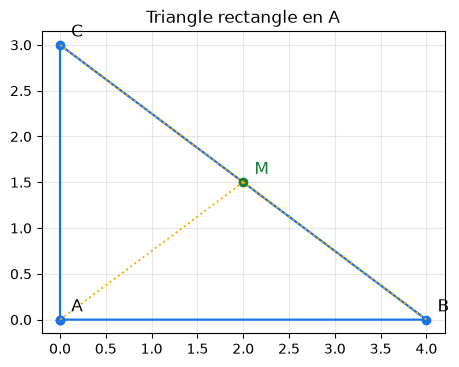

Distances mesurees sur la figure : {'MA': 2.5, 'MB': 2.5, 'MC': 2.5}


In [2]:
def draw_triangle(A, B, C, M=None, title=None):
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    ax.plot([A[0], B[0], C[0], A[0]], [A[1], B[1], C[1], A[1]], 'o-', color='#1a73e8', lw=1.6)
    for P, name in [(A, 'A'), (B, 'B'), (C, 'C')]:
        ax.annotate(name, P, textcoords="offset points", xytext=(8, 6), fontsize=12)
    if M is not None:
        ax.plot(*M, 'o', color='#188038')
        ax.annotate('M', M, textcoords="offset points", xytext=(8, 6), fontsize=12, color='#188038')
        for P in (A, B, C):
            ax.plot([M[0], P[0]], [M[1], P[1]], ':', color='#f9ab00', lw=1.4)
    ax.set_aspect('equal')
    ax.set_title(title or "Triangle rectangle en A")
    ax.grid(alpha=0.3)
    plt.show()

A = np.array([0.0, 0.0]); B = np.array([4.0, 0.0]); C = np.array([0.0, 3.0])
M = (B + C) / 2
draw_triangle(A, B, C, M)

d = {name: np.linalg.norm(M - P) for name, P in [('MA', A), ('MB', B), ('MC', C)]}
print("Distances mesurees sur la figure :", {k: round(float(v), 10) for k, v in d.items()})

Les trois distances affichées coïncident : la figure **suggère** fortement le théorème. Mais une figure n'est pas une preuve, pour deux raisons distinctes :

1. elle peut être **mal tracée** — des erreurs d'arrondi ou un dessin approximatif peuvent faire ressembler un triangle quelconque à un triangle rectangle ;
2. surtout, elle n'est qu'**un seul exemple**. Le théorème parle de *tous* les triangles rectangles, une infinité.

Ce notebook répond à la seconde objection par une machinerie explicite, puis mesure honnêtement ce qui manque encore.

> **Pour aller plus loin — Surviving proofs, *Why Do We Care About Proofs?* (29/08/2026)**
> Sheydvasser insiste sur le fait qu'une preuve n'est pas seulement un certificat de certitude, mais une *stratégie* qui éclaire. Une figure approchée ne donne ni l'un ni l'autre : ni la certitude (deux tracés peuvent se ressembler sans prouver la même chose), ni la stratégie (la méthode qui a produit le tracé reste cachée). Le passage « figure → équations » qu'on amorce ici commence précisément à *exposer* la stratégie, en remplaçant le coup d'œil par des polynômes explicites.
> *Senia Sheydvasser, The Deranged Mathematician (Substack), URL https://derangedmathematician.substack.com/p/why-do-we-care-about-proofs*
> *Archivé : G:\Mon Drive\MyIA\IA\Bibliographie IA\Pedagogie-Proves\Sheydvasser-Surviving-Proofs\2026-08-29_why-do-we-care-about-proofs.html*

## 2. Traduire l'énoncé en polynômes

Écrivons l'énoncé avec des coordonnées inconnues : $A(x_A, y_A)$, $B(x_B, y_B)$, $C(x_C, y_C)$, $M(x_M, y_M)$.

**L'hypothèse** « rectangle en $A$ » dit que les vecteurs $\vec{AB}$ et $\vec{AC}$ sont orthogonaux. Le produit scalaire nul donne un polynôme de degré 2 :

$$H \;\equiv\; (x_B - x_A)(x_C - x_A) + (y_B - y_A)(y_C - y_A) = 0.$$

**La définition** « $M$ est le milieu de $[BC]$ » donne deux équations affines, qu'on peut substituer :

$$x_M = \frac{x_B + x_C}{2}, \qquad y_M = \frac{y_B + y_C}{2}.$$

**La conclusion** « $MA = MB = MC$ » est une égalité de distances. On l'élève au carré (des distances positives sont égales ssi leurs carrés le sont), ce qui donne deux polynômes :

$$C_1 \;\equiv\; MA^2 - MB^2 = 0, \qquad C_2 \;\equiv\; MB^2 - MC^2 = 0.$$

Après substitution du milieu, $C_1$ et $C_2$ ne dépendent plus que des six coordonnées des sommets. Construisons-les avec `sympy` :

In [3]:
xA, yA, xB, yB, xC, yC = sp.symbols('x_A y_A x_B y_B x_C y_C')

# Hypothese : orthogonalite en A (produit scalaire nul)
H = (xB - xA) * (xC - xA) + (yB - yA) * (yC - yA)

# Definition du milieu M de [BC], substituee ensuite partout
xM = (xB + xC) / 2
yM = (yB + yC) / 2

MA2 = (xM - xA)**2 + (yM - yA)**2
MB2 = (xM - xB)**2 + (yM - yB)**2
MC2 = (xM - xC)**2 + (yM - yC)**2

C1 = sp.expand(MA2 - MB2)   # conclusion, 1re composante : MA^2 = MB^2
C2 = sp.expand(MB2 - MC2)   # conclusion, 2e composante : MB^2 = MC^2

print("H  =", H)
print("C1 =", C1)
print("C2 =", C2)
print("C2 est-il identiquement nul ?", sp.simplify(C2) == 0)
print("degres : H ->", sp.Poly(H, xA, yA, xB, yB, xC, yC).total_degree(),
      "| C1 ->", sp.Poly(C1, xA, yA, xB, yB, xC, yC).total_degree())

H  = (-x_A + x_B)*(-x_A + x_C) + (-y_A + y_B)*(-y_A + y_C)
C1 = x_A**2 - x_A*x_B - x_A*x_C + x_B*x_C + y_A**2 - y_A*y_B - y_A*y_C + y_B*y_C
C2 = 0
C2 est-il identiquement nul ? True
degres : H -> 2 | C1 -> 2


L'énoncé géométrique est devenu **deux polynômes actifs** en six variables — et le sympy vient de nous apprendre quelque chose :

- $H$ (degré 2) : l'**hypothèse** — la figure satisfait « rectangle en $A$ » exactement quand $H = 0$ ;
- $C_1$ (degré 2) : la part **non triviale** de la conclusion, $MA^2 = MB^2$ ;
- $C_2 \equiv 0$ : la part **gratuite**. $M$ étant le milieu de $[BC]$, l'égalité $MB = MC$ vaut pour *tout* segment, rectangle ou pas — c'est la médiatrice, pas le théorème. La conclusion « équidistant des trois sommets » ne coûte donc qu'une seule égalité substantielle : $MA = MB$.

Le théorème entier tient maintenant dans une phrase **algébrique** :

> Pour toute valeur des coordonnées : si $H = 0$ (et la figure non dégénérée), alors $C_1 = 0$.

C'est cette phrase que les notebooks 02 et 03 établiront *exactement*. Ici, nous allons la **tester**.

## 3. La vérification numérique : beaucoup de figures, un test

Plutôt qu'une figure, tirons-en dix mille. Pour être sûr de fabriquer des triangles rectangles, on ne tire pas $A$, $B$, $C$ au hasard et on ne vérifie pas l'angle après coup : on **construit** l'angle droit. Choisissons $A$ et une direction $u$ à coordonnées entières, posons $B = A + u$, puis $C = A + v$ où $v$ est $u$ tourné d'un quart de tour **puis allongé d'un facteur entier $k$ indépendant** — sans ce facteur, tous nos triangles seraient isocèles, une famille bien trop pauvre pour tester un théorème général. L'hypothèse $H = 0$ vaut alors **par construction** — sur des coordonnées entières, exactement.

In [4]:
def sample_right_triangles(n, span=20, rng=rng):
    """Tire n triangles ABC rectangles en A, sommets a coordonnees entieres dans [-span, span].

    B - A = u et C - A = v avec v orthogonal a u, mais de longueur INDEPENDANTE
    (v = k * rot(u), k entier non nul tire a part) : la famille couvre les triangles
    rectangles a cotes entiers (AB et AC independants), pas seulement les isoceles.
    Renvoie les six coordonnees en six tableaux de forme (n,).
    """
    a = rng.integers(-span, span + 1, size=(n, 2))      # A
    u = rng.integers(-span, span + 1, size=(n, 2))       # direction AB, non nulle a verifier
    ok = np.any(u != 0, axis=1)
    while not np.all(ok):                                # retirer les u nuls (triangle aplati)
        u[~ok] = rng.integers(-span, span + 1, size=((~ok).sum(), 2))
        ok = np.any(u != 0, axis=1)
    k = rng.integers(-span, span + 1, size=n)            # rapport des longueurs AC / AB
    nul = (k == 0)
    while np.any(nul):                                   # k non nul : C distinct de A
        k[nul] = rng.integers(-span, span + 1, size=nul.sum())
        nul = (k == 0)
    v = k[:, None] * np.stack([-u[:, 1], u[:, 0]], axis=1)  # v = k * rotation d'un quart de tour de u
    b = a + u
    c = a + v
    return a[:, 0], a[:, 1], b[:, 0], b[:, 1], c[:, 0], c[:, 1]

N = 10_000
xA_, yA_, xB_, yB_, xC_, yC_ = sample_right_triangles(N)

# Evaluation vectorisee des polynomes avec lambdify (numpy)
evalH  = sp.lambdify((xA, yA, xB, yB, xC, yC), H, 'numpy')
evalC1 = sp.lambdify((xA, yA, xB, yB, xC, yC), C1, 'numpy')

Hv, C1v = evalH(xA_, yA_, xB_, yB_, xC_, yC_), evalC1(xA_, yA_, xB_, yB_, xC_, yC_)
print(f"{N} triangles rectangles (coordonnees entieres, longueurs AB et AC independantes)")
print(f"max |H|  = {np.abs(Hv).max():.1f}   (hypothese, nulle par construction)")
print(f"max |C1| = {np.abs(C1v).max():.1f}   (MA^2 - MB^2, attendu : 0)")

10000 triangles rectangles (coordonnees entieres, longueurs AB et AC independantes)
max |H|  = 0.0   (hypothese, nulle par construction)
max |C1| = 0.0   (MA^2 - MB^2, attendu : 0)


**Lecture du résultat.** Sur les 10 000 figures, l'hypothèse est exactement satisfaite (coordonnées entières : aucune erreur d'arrondi) et la conclusion non triviale $C_1$ est **exactement nulle**, figure après figure. Le test dit :

> *Chaque fois que j'ai fabriqué un triangle rectangle, le milieu de l'hypoténuse était équidistant des trois sommets.*

Dix mille confirmations d'un coup — et pourtant, aucun mathématicien ne crierait « preuve ». La section 5 dira exactement pourquoi. Mais d'abord, assurons-nous que la machinerie ne répond pas « oui » à tout.

## 4. Témoin négatif : la machinerie sait aussi dire non

Un test qui valide tout ne prouve rien. Testons un **énoncé faux**, avec la même machinerie, sans prévenir le code :

> **Énoncé piège.** Dans un triangle $ABC$ rectangle en $A$, le milieu du côté $[AB]$ est équidistant de $A$ et de $C$.

Traduction : $M'$ milieu de $[AB]$, conclusion $C' \equiv M'A^2 - M'C^2 = 0$. Si la méthode est honnête, elle doit le **rejeter** sur la majorité des figures :

> **Pour aller plus loin — Surviving proofs, *Counterexamples and Contradictions* (12/09/2026)**
> Sheydvasser recommande de chercher le **contre-exemple le plus simple d'abord**, puis de raffiner. Ici, l'énoncé piège (M' milieu de [AB] équidistant de A et C) est précisément ce genre de contre-exemple *catégorique* — un seul test sur la bonne expression suffit, sans statistique. C'est le pattern « essayer de réfuter avant de chercher à prouver » que l'article 2 défend : si la machinerie ne sait pas dire non, elle ne sait rien dire.
> *Senia Sheydvasser, The Deranged Mathematician (Substack), URL https://derangedmathematician.substack.com/p/counterexamples-and-contradictions*
> *Archivé : G:\Mon Drive\MyIA\IA\Bibliographie IA\Pedagogie-Proves\Sheydvasser-Surviving-Proofs\2026-09-12_counterexamples-and-contradictions.html*

In [5]:
xMp = (xA + xB) / 2            # milieu M' du cote [AB]
yMp = (yA + yB) / 2
Cp = sp.expand((xMp - xA)**2 + (yMp - yA)**2 - ((xMp - xC)**2 + (yMp - yC)**2))

evalCp = sp.lambdify((xA, yA, xB, yB, xC, yC), Cp, 'numpy')
Cpv = evalCp(xA_, yA_, xB_, yB_, xC_, yC_)

nonzero = np.abs(Cpv) > 0
print(f"Enonce piege evalue sur les memes {N} figures :")
print(f"  figures qui le REFUTENT  (C' != 0) : {nonzero.sum():5d} / {N}")
print(f"  figures qui le 'valident' (C' = 0) : {(~nonzero).sum():5d} / {N}")
print(f"  max |C'| = {np.abs(Cpv).max():.0f}")

# Que vaut exactement C' sur une figure qui satisfait l'hypothese ?
AC2 = (xC - xA)**2 + (yC - yA)**2
print("Identite exacte C' + AC^2 - H = 0 ?", sp.expand(Cp + AC2 - H) == 0)

Enonce piege evalue sur les memes 10000 figures :
  figures qui le REFUTENT  (C' != 0) : 10000 / 10000
  figures qui le 'valident' (C' = 0) :     0 / 10000
  max |C'| = 304400
Identite exacte C' + AC^2 - H = 0 ? True


**Lecture du résultat.** L'énoncé piège est rejeté sur **toutes** les figures : le test **discrimine**, il n'est pas un moulin à « oui ». Et le rejet est catégorique, pas statistique : la dernière ligne le montre, l'identité exacte $C' = H - AC^2$ vaut pour *toute* figure — donc $C' = -AC^2$ sur les figures rectangle en $A$, strictement négatif dès que $C \neq A$.

Le test numérique distingue donc déjà trois régimes : **toujours vrai** (le fil rouge), **toujours faux** (le piège ci-dessus), et — l'exercice 2 en fabriquera un — **parfois vrai** : un énoncé qui ne tient que sur une sous-famille de figures. Cette catégorie intermédiaire, la plus sournoise pour un test numérique, est exactement celle que l'algèbre du notebook 02 traitera proprement, via les **conditions de non-dégénérescence**.

> **Pour aller plus loin — Surviving proofs, *Counterexamples and Contradictions* (12/09/2026, suite)**
> Sheydvasser note qu'un contre-exemple *exact* (ici, l'identité $C' = H - AC^2$ qui vaut $-AC^2 < 0$ sur tout triangle rectangle non dégénéré) est plus probant qu'un rejet statistique. La machinerie numérique fait ici *les deux* : elle rejette sur 10 000 figures, mais la cellule markdown qui suit exhibe l'identité algébrique qui fonde le rejet. C'est exactement le geste « contre-exemple d'abord, puis explication » qu'elle recommande dans son article 2.
> *Senia Sheydvasser, The Deranged Mathematician (Substack), URL https://derangedmathematician.substack.com/p/counterexamples-and-contradictions*
> *Archivé : G:\Mon Drive\MyIA\IA\Bibliographie IA\Pedagogie-Proves\Sheydvasser-Surviving-Proofs\2026-09-12_counterexamples-and-contradictions.html*

## 5. Pourquoi ce n'est pas encore une preuve

L'objection logique au test numérique tient en un fait d'algèbre élémentaire :

> **Un polynôme non nul peut s'annuler en certains points.**

$\;q(x, y) = x^2 + y^2 - 25$ n'est pas le polynôme nul, pourtant $q(3, 4) = 0$ et $q(0, 5) = 0$ — tous les points du cercle de rayon 5 l'annulent. Réciproquement, si l'on teste $q$ **uniquement sur des points du cercle**, on conclura à tort « $q \equiv 0$ ».

Appliqué à notre théorème : nos 10 000 figures sont peut-être, sans qu'on le sache, l'équivalent du cercle — un ensemble de points soigneusement choisi sur lequel la conclusion s'annule *par accident*, alors qu'elle échoue ailleurs. La construction de la section 3 (rotation d'un quart de tour) paraît innocente ; **paraît** ne suffit pas en mathématiques. Fabriquons le piège explicitement, pour le voir de nos yeux :

In [6]:
# Le piege, joue en pleine lumiere : tester q(x, y) = x^2 + y^2 - 25
# uniquement sur le cercle de rayon 5 (points entiers de Pythagore).
q = sp.Lambda((xA, yA), xA**2 + yA**2 - 25)

pythagorean = [(3, 4), (4, 3), (0, 5), (5, 0), (-3, 4), (-4, -3), (3, -4)]
vals_on_circle = [q(*p) for p in pythagorean]
print("q evalue sur des points DU cercle de rayon 5 :", vals_on_circle)
print("-> tirage biaise : on croirait q == 0 partout")

vals_elsewhere = [q(1, 1), q(2, 0), q(10, 10), q(0, 0)]
print("q evalue sur des points QUELCONQUES          :", vals_elsewhere)
print("-> le meme polynome, evalue ailleurs, n'est plus nul")

q evalue sur des points DU cercle de rayon 5 : [0, 0, 0, 0, 0, 0, 0]
-> tirage biaise : on croirait q == 0 partout
q evalue sur des points QUELCONQUES          : [-23, -21, 175, -25]
-> le meme polynome, evalue ailleurs, n'est plus nul


**Ce que démontre le piège.** La validité du test numérique dépend entièrement du **mode de tirage** des figures. Tirer « au hasard dans une grande grille » est une parade — mais elle appelle deux questions :

1. quelle est la probabilité qu'un polynôme non nul s'annule sur un point *réellement aléatoire* ?
2. peut-on la **majorer**, sans connaître le polynôme d'avance ?

La réponse à ces deux questions est un théorème célèbre, et c'est lui qui sauve l'honneur du test numérique.

## 6. Schwartz–Zippel : le test devient preuve probabiliste

> **Lemme (Schwartz–Zippel, 1980).** Soit $P \neq 0$ un polynôme de degré total $d$ en $n$ variables, et $S$ un ensemble fini de nombres. Si on tire chaque variable **indépendamment et uniformément** dans $S$, alors
> $$\Pr\big[\,P(x_1, \dots, x_n) = 0\,\big] \;\le\; \frac{d}{|S|}.$$

Autrement dit : un polynôme non nul ne s'annule que rarement sur un point *réellement* aléatoire — au plus $d/|S|$ du temps. Un polynôme de degré 2, testé sur la grille des entiers de $-100$ à $100$ ($|S| = 201$), a moins de $1\ \%$ de chance de faux zéro par tirage.

Vérifions le lemme **empiriquement** sur un polynôme non nul de degré 2, en comptant le taux d'annulation exact sur des grilles entières de tailles croissantes :

> **Pour aller plus loin — Surviving proofs, *Heuristics and Numerics* (19/09/2026)**
> Sheydvasser insiste : « accumuler des données n'est pas inférer ; il faut un *modèle* qu'on cherche à réfuter ». Le lemme Schwartz-Zippel est précisément cette formalisation : un polynôme non nul est un *modèle* dont la probabilité de faux-zéro sous tirage uniforme est bornée par $d/|S|$. Le test numérique devient une preuve probabiliste *parce qu'on a exhibé le modèle* — c'est le geste « formuler un modèle réfutable » qu'elle recommande.
> *Senia Sheydvasser, The Deranged Mathematician (Substack), URL https://derangedmathematician.substack.com/p/heuristics-and-numerics*
> *Archivé : G:\Mon Drive\MyIA\IA\Bibliographie IA\Pedagogie-Proves\Sheydvasser-Surviving-Proofs\2026-09-19_heuristics-and-numerics.html*

In [7]:
# Mesure du taux d'annulation d'un polynome non nul de degre 2 sur des grilles entieres.
# Polynome temoin : P(u, v) = u*v + u^2  (non nul, degre total 2).
def zero_rate_on_grid(half_span):
    span = np.arange(-half_span, half_span + 1)
    U, V = np.meshgrid(span, span)
    vals = U * V + U**2
    return (vals == 0).mean(), span.size

print(f"{'grille':>16} | {'taux de zeros mesure':>20} | {'borne S-Z  d/|S|':>16}")
print("-" * 62)
for half_span in (2, 5, 10, 50):
    rate, size = zero_rate_on_grid(half_span)
    print(f"{f'[-{half_span}, {half_span}]':>16} | {rate:>20.4f} | {2 / size:>16.4f}")

          grille | taux de zeros mesure | borne S-Z  d/|S|
--------------------------------------------------------------
         [-2, 2] |               0.3600 |           0.4000
         [-5, 5] |               0.1736 |           0.1818
       [-10, 10] |               0.0930 |           0.0952
       [-50, 50] |               0.0197 |           0.0198


**Lecture du résultat.** Sur chaque grille, le taux de zéros mesuré reste **sous la borne** $d/|S| = 2/|S|$, et décroît comme $1/|S|$ quand la grille grandit. Le lemme n'est pas une abstraction : c'est une propriété mesurable de nos polynômes.

Appliquons-le au fil rouge — avec une précaution décisive. Tirer les six coordonnées au hasard puis ne garder que les figures rectangle ne teste presque rien : l'hypothèse $H = 0$ est si maigre en points de la grille qu'un tirage uniforme ne la rencontre pratiquement jamais (le taux se mesure en dix-millièmes — la cellule suivante le mesure). La bonne machine est celle de la section 3 : **substituer la construction paramétrique** $A = (0, 0)$, $B = u$, $C = k \cdot \mathrm{rot}(u)$ dans la conclusion. L'hypothèse est alors satisfaite *par construction* — chaque tirage de $(u_1, u_2, k)$ est une vraie figure — et $C_1$ devient un polynôme des paramètres, $C_1(u_1, u_2, k)$, de degré au plus 4 : les coordonnées substituées sont linéaires en $(u_1, u_2)$ mais **quadratiques** avec $k$ ($x_C = -k u_2$, $y_C = k u_1$), donc un polynôme de degré 2 en les coordonnées ($x_C^2$, $x_B x_C$…) devient de degré au plus 4 en les paramètres ($k^2 u_2^2$, $k u_1 u_2$…). Le protocole probabiliste devient :

1. tirer les paramètres $(u_1, u_2, k)$ **uniformément et indépendamment** dans une grande grille d'entiers ($|S| = 201$, disons) ;
2. si un tirage rend $C_1 \neq 0$, le théorème est **réfuté** — et cette réfutation est un certificat *certain* : exhiber un seul contre-exemple suffit ;
3. si tous les tirages rendent $0$, deux explications restent possibles : $C_1(u_1, u_2, k)$ est identiquement nul — le théorème est alors une **identité**, vraie sur toute la famille construite — ou bien tous nos tirages sont tombés dans les zéros accidentels d'un polynôme non nul ;
4. Schwartz–Zippel borne la seconde explication : pour un polynôme non nul de degré $d$, au plus $d/|S| = 4/201 \approx 2\,\%$ par tirage — et cette borne se **compose** sur des tirages indépendants.

In [8]:
# Etape 0 : pourquoi ne PAS tirer les six coordonnees puis filtrer H = 0 ?
# Mesure : taux de figures rectangles rencontrees au hasard dans [-100, 100]^6.
N_probe = 200_000
pts = rng.integers(-100, 101, size=(N_probe, 6))
xA_, yA_, xB_, yB_, xC_, yC_ = pts.T
H_vals = (xB_ - xA_) * (xC_ - xA_) + (yB_ - yA_) * (yC_ - yA_)
print(f"figures rectangle rencontrees au hasard : {int(np.sum(H_vals == 0))} / {N_probe}"
      f"  (taux {np.mean(H_vals == 0):.2e})")

# Etape 1 : le protocole correct -- substituer la construction de la section 3
# (A = origine, B = u, C = k * rot(u) avec rot(x, y) = (-y, x)) dans C1.
u1, u2, kk = sp.symbols('u_1 u_2 k', integer=True)
subs_params = {xA: 0, yA: 0, xB: u1, yB: u2, xC: -kk * u2, yC: kk * u1}
C1_param = sp.expand(C1.subs(subs_params))
print("C1 apres substitution des parametres :", C1_param)
print("C1(u_1, u_2, k) identiquement nul ?", C1_param == 0)

# Etape 2 : Schwartz-Zippel au travail -- 100 tirages uniformes de (u_1, u_2, k).
f_C1p = sp.lambdify((u1, u2, kk), C1_param, 'numpy')
params = rng.integers(-100, 101, size=(100, 3))
raw = f_C1p(params[:, 0], params[:, 1], params[:, 2])
vals = np.broadcast_to(np.asarray(raw, dtype=float), (len(params),))
print(f"tirages de parametres : {len(vals)} | rendant C1 = 0 : {int(np.sum(vals == 0))} / {len(vals)}")

# Etape 3 : la puissance du protocole -- la borne se compose sur les tirages.
for n_draws in (1, 10, 100):
    p_false = (4 / 201) ** n_draws
    print(f"{n_draws:>3} tirages independants : Pr[faux accord] <= {p_false:.2e}")

figures rectangle rencontrees au hasard : 56 / 200000  (taux 2.80e-04)
C1 apres substitution des parametres : 0
C1(u_1, u_2, k) identiquement nul ? True
tirages de parametres : 100 | rendant C1 = 0 : 100 / 100
  1 tirages independants : Pr[faux accord] <= 1.99e-02
 10 tirages independants : Pr[faux accord] <= 9.74e-18
100 tirages independants : Pr[faux accord] <= 7.70e-171


**Lecture du résultat.** La mesure d'abord : sur 200 000 tirages uniformes des six coordonnées, une cinquantaine à peine satisfont l'hypothèse — filtrer $H = 0$ a posteriori n'aurait donc presque rien testé. Avec la substitution, chaque tirage de paramètres est une vraie figure, et les 100 tirages rendent tous $C_1 = 0$. Un polynôme *non nul* de degré au plus 4 n'aurait survécu à 100 tirages uniformes qu'avec probabilité au plus $(4/201)^{100} \approx 8 \times 10^{-171}$ : soit nous avons observé l'improbable, soit $C_1(u_1, u_2, k)$ est **identiquement nul** — et sympy tranche : l'identité est exacte. Le test probabiliste et le verdict exact concordent. C'est le principe des **tests d'identité polynomiale** (PIT), pilier de l'algorithmique moderne (fingerprinting, vérification de calculs, preuves PCP).

Mais notons bien les **limites** : la borne ne s'applique qu'à un polynôme non nul sur un tirage *réellement* uniforme — un adversaire qui connaît notre générateur peut construire un énoncé faux qui s'annule sur toute notre grille (la section 5 l'a joué en pleine lumière). Et l'identité après substitution est vérifiée **sur la famille construite** ; la question générale — toute figure, y compris les cas dégénérés, avec la liste explicite des non-dégénérescences — reste ouverte. La certitude absolue exige l'algèbre exacte.

## 7. Ce que le Geometry-02 ajoutera : la certitude

Le test numérique répond « pas de contre-exemple trouvé ». La question mathématique est plus forte :

> La conclusion est-elle **consignée dans les hypothèses** — au sens où $C_1$ et $C_2$ s'annulent forcément dès que $H$ s'annule (et la figure n'est pas dégénérée) ?

C'est une question d'**algèbre des polynômes** : la conclusion doit appartenir à l'idéal engendré par les hypothèses — notion que le Geometry-02 (*Prouver par l'algèbre*) construira pas à pas, avant d'invoquer son outil natif, la **base de Gröbner** de `sympy`. Cette appartenance, elle, se décide **exactement**, sans probabilité :

| Question | Test numérique (01) | Algèbre exacte (02, 03) |
|---|---|---|
| Le théorème est-il réfuté par une figure ? | oui — certificat certain | n/a (le cas est réglé) |
| Le théorème vaut-il sur *toutes* les figures ? | non — au mieux probabiliste | **oui ou non, certain** |
| Sur quelles figures dégénérées échoue-t-il ? | au hasard des tirages | **listées explicitement** (non-dégénérescences) |

La série poursuit : le 03 reprendra le même théorème par la **méthode de Wu** — une autre algèbre exacte, plus proche de ce que les systèmes géométriques automatisés utilisent réellement — et le 05 posera la question du pont vers les preuves **formelles** Lean : que garantit exactement « prouvé par Gröbner » ?

## 8. Exercices

Trois exercices pour vous approprier la machinerie. Les cellules sont des **stubs non bloquants** : le notebook s'exécute de bout en bout même non complété (les vôtres, une fois remplis, doivent s'exécuter sans erreur).

### Exercice 1 — Pythagore par la même méthode

Le théorème de Pythagore est un autre habitué des triangles rectangles. Traduisez-le en polynôme et testez-le sur les figures de la section 3 :

> **Énoncé.** Dans un triangle rectangle en $A$ : $AB^2 + AC^2 = BC^2$.

**Étapes suggérées.**
1. Écrire le polynôme $P \equiv AB^2 + AC^2 - BC^2$ avec `sympy` (aucun besoin du milieu).
2. L'évaluer sur les tirages `xA_, yA_, xB_, yB_, xC_, yC_` de la section 3 avec `lambdify`.
3. Vérifier que `max |P|` est exactement nul (coordonnées entières : aucune erreur d'arrondi), et interpréter : ce test *confirme* Pythagore sur 10 000 figures.

In [9]:
# Exercice 1 : Pythagore comme identite polynomiale sur les memes figures
# TODO etudiant : definir P = AB^2 + AC^2 - BC^2 avec sympy, puis l'evaluer sur les tirages.
# Indice : AB2 = (xB - xA)**2 + (yB - yA)**2 ; reutiliser le pattern lambdify de la section 3.
print("Exercice a completer")

Exercice a completer


### Exercice 2 — Un énoncé « parfois vrai »

La section 4 a laissé entrevoir des énoncés ni toujours ni jamais vrais. Étudiez-en un proprement :

> **Énoncé.** Dans un triangle $ABC$ rectangle en $A$, le milieu $M$ de $[BC]$ est équidistant du milieu $M'$ de $[AB]$ et du milieu $M''$ de $[AC]$.

**Étapes suggérées.**
1. Écrire le polynôme $Q \equiv MM'^2 - MM''^2$ en substituant les trois milieux (une ligne par milieu, comme en section 2).
2. L'évaluer sur les tirages ; compter la fraction de figures où $Q = 0$ exactement (coordonnées entières).
3. Caractériser quelques figures qui « valident » : que partagent-elles ? (Piste : comparer les longueurs $AB$ et $AC$ ; la fraction attendue avoisine 5 % — réfléchissez à pourquoi ce chiffre, et pas un autre.)

In [10]:
# Exercice 2 : taux de validation d'un enonce parfois vrai
# TODO etudiant : construire Q = MM'^2 - MM''^2 (trois milieux substitues), l'evaluer,
# compter la fraction de figures ou Q == 0 exactement.
# Indice : comparer |AB| et |AC| sur les figures validantes ; afficher 2-3 de ces figures.
print("Exercice a completer")

Exercice a completer


### Exercice 3 — Schwartz–Zippel sous contrainte

La borne du lemme suppose un tirage **uniforme**. Que se passe-t-il quand on la viole ?

**Étapes suggérées.**
1. Pour $q(x, y) = x^2 + y^2 - 25$, mesurer le taux de zéros sur la grille entière $[-10, 10]^2$ — il doit rester sous la borne $2/21$.
2. Mesurer de nouveau, mais en ne tirant **que des points du cercle** : les triplets pythagoriciens $(3,4)$, $(4,3)$, $(0,5)$, $(5,0)$ et leurs signes suffisent.
3. Comparer les deux taux et conclure : que devient la borne quand le tirage n'est plus uniforme ? Relisez la section 5 : c'est exactement le biais qui séparait le test numérique d'une preuve.

In [11]:
# Exercice 3 : taux d'annulation uniforme vs biaise pour q = x^2 + y^2 - 25
# TODO etudiant : deux taux a mesurer, un comparatif a ecrire.
# Indice : grille -> np.meshgrid(np.arange(-10, 11), ...) ; cercle -> liste explicite de triplets.
print("Exercice a completer")

Exercice a completer


## Ce qu'il faut retenir

- **Traduction** : hypothèse et conclusion d'un théorème de géométrie s'écrivent comme des **polynômes** sur les coordonnées — ici **deux polynômes actifs** de degré 2 pour le fil rouge (la troisième composante, $MB = MC$, est la médiatrice : identiquement nulle).
- **Test numérique** : sur 10 000 figures construites, la conclusion tient **exactement** (coordonnées entières : aucune erreur d'arrondi) ; la même machinerie **rejette** un énoncé piège — elle discrimine.
- **Limite** : un polynôme non nul s'annule sur des points épars ; un tirage biaisé peut donc faire passer un énoncé faux pour une identité (le piège du cercle).
- **Sauvetage partiel** : Schwartz–Zippel majore la probabilité de faux accord d'un tirage uniforme par $d/|S|$ — le test numérique devient une **preuve probabiliste** à marge explicite, jamais une certitude.

La suite — Geometry-02, *Prouver par l'algèbre* — établira la certitude : l'appartenance de la conclusion à l'idéal des hypothèses, décidée exactement par les bases de Gröbner, avec la liste explicite des conditions de non-dégénérescence.

***
*Coût d'exécution : ~5 s sur CPU (kernel `python3`, 10 000 tirages vectorisés `numpy`, zéro appel réseau). Reproductibilité : HIGH — le générateur aléatoire est semé (`rng` seed 20260923), toutes les cellules sont déterministes à l'affichage près.*